# Tasks

## P 7.1: Download the adult_T7 dataset from Canvas. Use four classifiers to predict the 'income' column. Calculate all evaluation metrics using a five-fold cross-validation. Print the feature importance values from the random forest classifier. You should improve your models as best as you can (10%).

In [ ]:
############# WRITE YOUR CODE IN THIS CELL (IF APPLICABLE)  ####################

import pandas as pd
import numpy as np

from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

df = pd.read_csv(r"/adult_T7.csv")
df.head()

X = df.drop("income", axis=1)
y = df["income"]

num_cols = X.select_dtypes(include=["int64", "float64"]).columns
cat_cols = X.select_dtypes(include=["object"]).columns

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
    ]
)


models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "KNN": KNeighborsClassifier(n_neighbors=7),
    "Decision Tree": DecisionTreeClassifier(max_depth=10),
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        max_depth=12,
        random_state=42
    )
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    "accuracy": "accuracy",
    "precision": "precision_macro",
    "recall": "recall_macro",
    "f1": "f1_macro"
}


for name, model in models.items():
    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("classifier", model)
    ])
    
    scores = cross_validate(pipe, X, y, cv=cv, scoring=scoring)
    
    print(f"\n{name}")
    print("Accuracy :", scores["test_accuracy"].mean())
    print("Precision:", scores["test_precision"].mean())
    print("Recall   :", scores["test_recall"].mean())
    print("F1 Score :", scores["test_f1"].mean())


rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", models["Random Forest"])
])

rf_pipeline.fit(X, y)


feature_names = (
    rf_pipeline.named_steps["preprocessor"]
    .get_feature_names_out()
)

importances = rf_pipeline.named_steps["classifier"].feature_importances_

feature_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

print(feature_importance_df.head(15))




Logistic Regression
Accuracy : 0.85
Precision: 0.8063449604823593
Recall   : 0.7641643117557732
F1 Score : 0.7812013483991287

KNN
Accuracy : 0.8276999999999999
Precision: 0.7685754867189956
Recall   : 0.7432727027453693
F1 Score : 0.7541223531305105

Decision Tree
Accuracy : 0.8519
Precision: 0.8080242696815825
Recall   : 0.7699071743036942
F1 Score : 0.7855628479065297

Random Forest
Accuracy : 0.8571000000000002
Precision: 0.8283265975188625
Recall   : 0.7583217229839594
F1 Score : 0.7835080400208838
                                   Feature  Importance
3                        num__capital-gain    0.134809
34  cat__marital-status_Married-civ-spouse    0.118092
2                       num__education-num    0.094469
55               cat__relationship_Husband    0.093706
0                                 num__age    0.071472
5                      num__hours-per-week    0.050305
36       cat__marital-status_Never-married    0.041175
4                        num__capital-loss    0.03

## P 7.2: Use two clustering methods to cluster a numerical column in the dataset. Find the optimum number of clusters using the elbow method (5%).  

## NOTE: Please complete this task in the next week's workshop
## NOTE: You can use any aptional numerical column for this task.

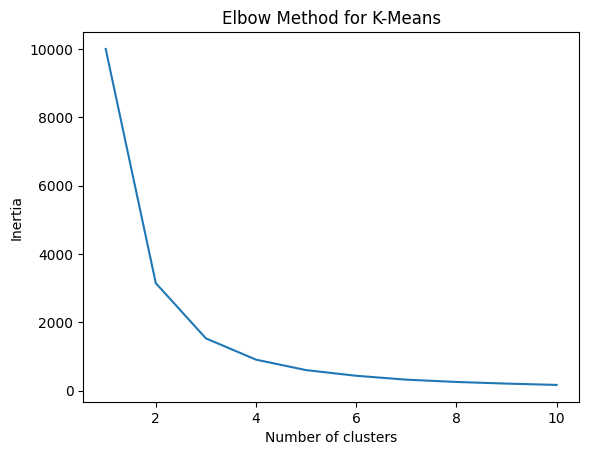

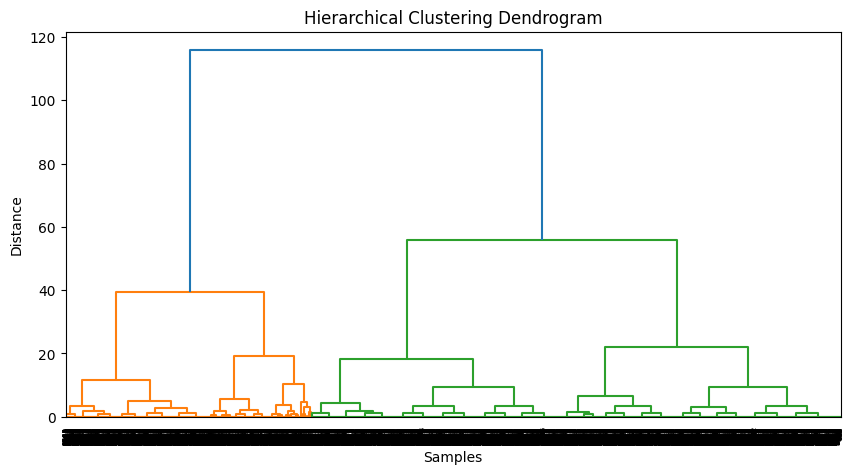

In [11]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage


num_data = df[["age"]] 

scaler = StandardScaler()
scaled_data = scaler.fit_transform(num_data)

inertia = []

K = range(1, 11)
for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_data)
    inertia.append(kmeans.inertia_)

plt.plot(K, inertia)
plt.xlabel("Number of clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method for K-Means")
plt.show()

linked = linkage(scaled_data, method="ward")

plt.figure(figsize=(10, 5))
dendrogram(linked)
plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Samples")
plt.ylabel("Distance")
plt.show()
